In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Experiment 1
## Multiple Linear Regression – Body Weight Prediction

### Question 2
To build a Multiple Linear Regression model to predict a person's
body weight using height, age and gender.

In [3]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# ============================================
# 2. CREATE DATASET
# ============================================

data = {
    "Weight": [
        79, 69, 73, 95, 82,
        55, 69, 71, 64, 69
    ],

    "Height": [
        1.80, 1.68, 1.78, 1.70, 1.87,
        1.59, 1.50, 1.78, 1.67, 1.64
    ],

    "Age": [
        35, 39, 25, 60, 27,
        18, 89, 42, 16, 52
    ],

    "Gender": [
        "Male", "Male", "Male", "Male", "Male",
        "Female", "Female", "Female", "Female", "Female"
    ]
}

df = pd.DataFrame(data)

print("Dataset created successfully!")

display(df)

Dataset created successfully!


,Weight,Height,Age,Gender
0,79,1.80,35,Male
1,69,1.68,39,Male
2,73,1.78,25,Male
3,95,1.70,60,Male
4,82,1.87,27,Male
5,55,1.59,18,Female
6,69,1.50,89,Female
7,71,1.78,42,Female
8,64,1.67,16,Female
9,69,1.64,52,Female


In [5]:
# ============================================
# 3. DATASET INFORMATION
# ============================================

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape:
(10, 4)

Column Names:
['Weight', 'Height', 'Age', 'Gender']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Weight  10 non-null     int64  
 1   Height  10 non-null     float64
 2   Age     10 non-null     int64  
 3   Gender  10 non-null     object 
dtypes: float64(1), int64(2), object(1)
memory usage: 452.0+ bytes


In [6]:
# ============================================
# 4. STATISTICAL SUMMARY
# ============================================

print("Statistical Summary:")

display(df.describe().T)

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Weight,10.0,72.600,10.834103,55.0,69.0000,70.00,77.50,95.00
Height,10.0,1.701,0.109894,1.5,1.6475,1.69,1.78,1.87
Age,10.0,40.300,22.181323,16.0,25.5000,37.00,49.50,89.00


In [7]:
# ============================================
# 5. MISSING VALUE ANALYSIS
# ============================================

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

print("Missing Values Summary:")

display(missing_summary)

Missing Values Summary:


,Missing Values,Percentage
Weight,0,0.0
Height,0,0.0
Age,0,0.0
Gender,0,0.0


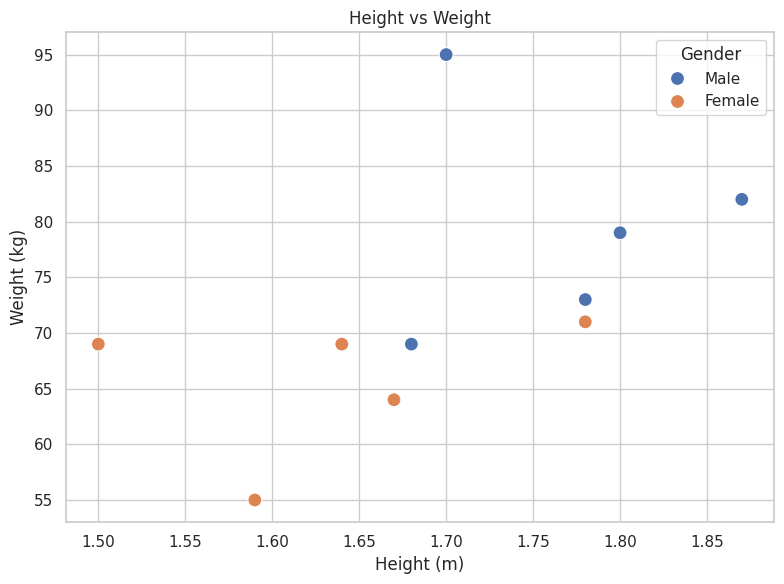

In [8]:
# ============================================
# 6. DATA VISUALIZATION
# ============================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Height",
    y="Weight",
    hue="Gender",
    s=100
)

plt.title("Height vs Weight")
plt.xlabel("Height (m)")
plt.ylabel("Weight (kg)")

plt.tight_layout()
plt.show()

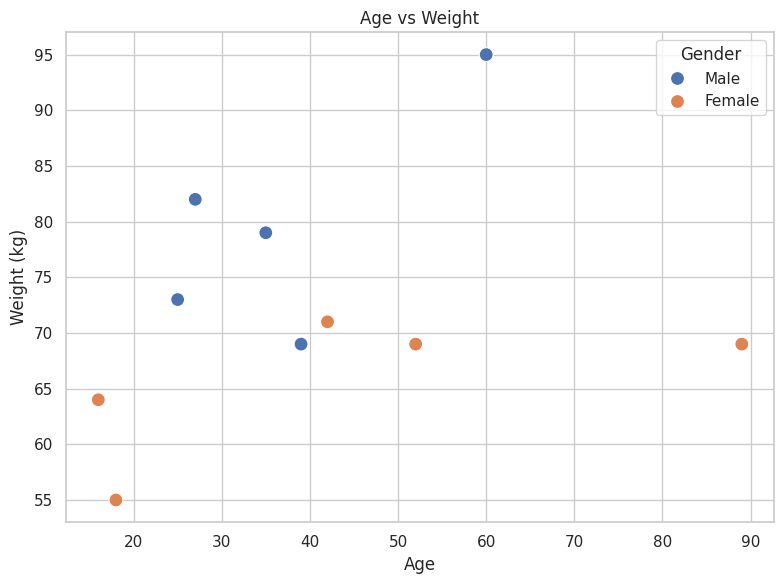

In [9]:
# ============================================
# 7. AGE VS WEIGHT VISUALIZATION
# ============================================

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Age",
    y="Weight",
    hue="Gender",
    s=100
)

plt.title("Age vs Weight")
plt.xlabel("Age")
plt.ylabel("Weight (kg)")

plt.tight_layout()
plt.show()


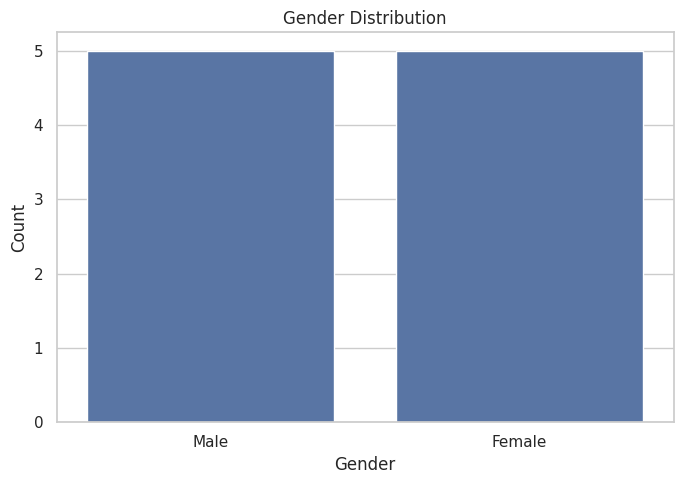

In [10]:
# ============================================
# 8. GENDER DISTRIBUTION
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [11]:
# ============================================
# 9. ENCODE GENDER
# ============================================

df["Gender_Encoded"] = df["Gender"].map({
    "Female": 0,
    "Male": 1
})

print("Dataset after encoding Gender:")

display(df)

Dataset after encoding Gender:


,Weight,Height,Age,Gender,Gender_Encoded
0,79,1.80,35,Male,1
1,69,1.68,39,Male,1
2,73,1.78,25,Male,1
3,95,1.70,60,Male,1
4,82,1.87,27,Male,1
5,55,1.59,18,Female,0
6,69,1.50,89,Female,0
7,71,1.78,42,Female,0
8,64,1.67,16,Female,0
9,69,1.64,52,Female,0


Correlation Matrix:


,Height,Age,Gender_Encoded,Weight
Height,1.000000,-0.506556,0.623474,0.498721
Age,-0.506556,1.000000,-0.147317,0.306173
Gender_Encoded,0.623474,-0.147317,1.000000,0.681058
Weight,0.498721,0.306173,0.681058,1.000000


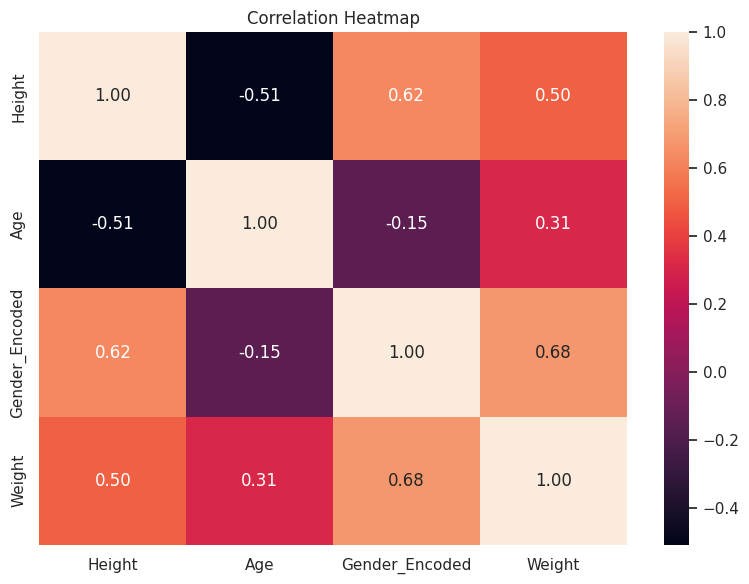

In [12]:
# ============================================
# 10. CORRELATION ANALYSIS
# ============================================

correlation = df[
    ["Height", "Age", "Gender_Encoded", "Weight"]
].corr()

print("Correlation Matrix:")

display(correlation)


plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [13]:
# ============================================
# 11. DEFINE FEATURES AND TARGET
# ============================================

# Independent Variables

X = df[
    ["Height", "Age", "Gender_Encoded"]
]

# Dependent Variable

y = df["Weight"]

print("Independent Variables:")

display(X)

print("\nDependent Variable:")

display(y)


Independent Variables:


,Height,Age,Gender_Encoded
0,1.80,35,1
1,1.68,39,1
2,1.78,25,1
3,1.70,60,1
4,1.87,27,1
5,1.59,18,0
6,1.50,89,0
7,1.78,42,0
8,1.67,16,0
9,1.64,52,0



Dependent Variable:


,Weight
0,79
1,69
2,73
3,95
4,82
5,55
6,69
7,71
8,64
9,69


In [14]:
# ============================================
# 12. TRAIN-TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 8
Testing samples : 2


In [15]:
# ============================================
# 13. TRAIN MULTIPLE LINEAR REGRESSION MODEL
# ============================================

model = LinearRegression()

model.fit(X_train, y_train)

print("Multiple Linear Regression model trained successfully!")

Multiple Linear Regression model trained successfully!


In [16]:
# ============================================
# 14. DISPLAY MODEL EQUATION
# ============================================

print("Intercept:", model.intercept_)

print("\nCoefficients:")

for feature, coefficient in zip(
    X.columns,
    model.coef_
):
    print(f"{feature}: {coefficient:.4f}")

Intercept: -22.51020537239242

Coefficients:
Height: 43.5844
Age: 0.3498
Gender_Encoded: 13.9986


In [17]:
# ============================================
# 15. MAKE PREDICTIONS
# ============================================

y_pred = model.predict(X_test)

print("Predicted Weights:")

print(y_pred)

Predicted Weights:
[55.87223226 78.35169463]


In [18]:
# ============================================
# 16. COMPARE ACTUAL AND PREDICTED VALUES
# ============================================

results = pd.DataFrame({
    "Actual Weight": y_test.values,
    "Predicted Weight": y_pred,
    "Difference": y_test.values - y_pred
})

print("Actual vs Predicted Results:")

display(results)

Actual vs Predicted Results:


,Actual Weight,Predicted Weight,Difference
0,64,55.872232,8.127768
1,69,78.351695,-9.351695


In [19]:
# ============================================
# 17. MODEL EVALUATION
# ============================================

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("=" * 50)
print(" MULTIPLE LINEAR REGRESSION MODEL RESULTS")
print("=" * 50)

print(f"MAE       : {mae:.4f}")
print(f"MSE       : {mse:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"R² Score  : {r2:.4f}")

print("=" * 50)

 MULTIPLE LINEAR REGRESSION MODEL RESULTS
MAE       : 8.7397
MSE       : 76.7574
RMSE      : 8.7611
R² Score  : -11.2812


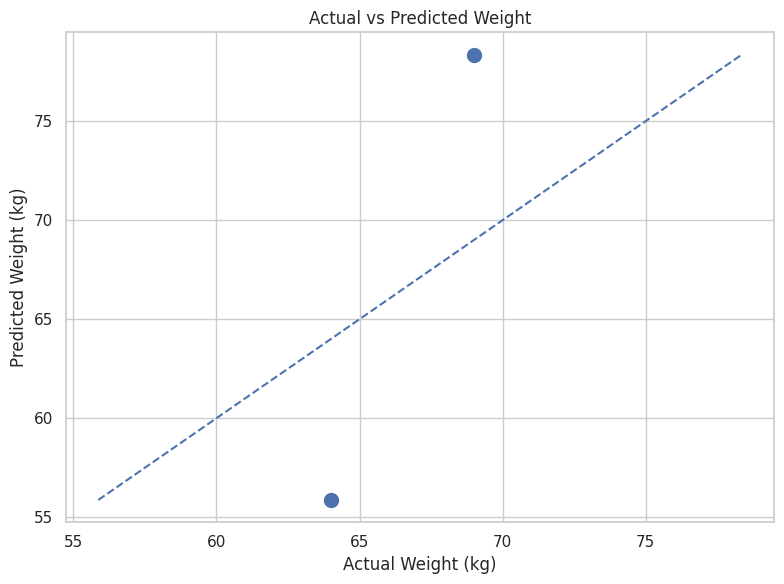

In [20]:
# ============================================
# 18. ACTUAL VS PREDICTED WEIGHT GRAPH
# ============================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    s=100
)

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Weight (kg)")
plt.ylabel("Predicted Weight (kg)")
plt.title("Actual vs Predicted Weight")

plt.tight_layout()
plt.show()

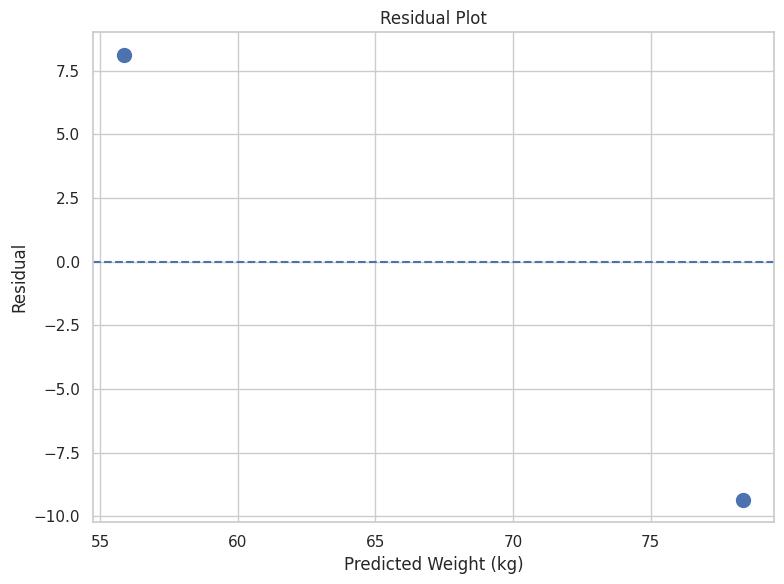

In [21]:
# ============================================
# 19. RESIDUAL ANALYSIS
# ============================================

residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred,
    residuals,
    s=100
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Weight (kg)")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.tight_layout()
plt.show()

In [22]:
# ============================================
# 20. FINAL MODEL SUMMARY
# ============================================

print("\nFINAL MODEL SUMMARY")

print("Model Type: Multiple Linear Regression")

print("\nIndependent Variables:")
print("- Height")
print("- Age")
print("- Gender")

print("\nDependent Variable:")
print("- Weight")

print("\nRegression Equation:")

print(
    f"Weight = {model.intercept_:.4f} "
    f"+ ({model.coef_[0]:.4f} × Height) "
    f"+ ({model.coef_[1]:.4f} × Age) "
    f"+ ({model.coef_[2]:.4f} × Gender)"
)


FINAL MODEL SUMMARY
Model Type: Multiple Linear Regression

Independent Variables:
- Height
- Age
- Gender

Dependent Variable:
- Weight

Regression Equation:
Weight = -22.5102 + (43.5844 × Height) + (0.3498 × Age) + (13.9986 × Gender)
